## nn.Linear layer version

## Try now with EEG simulations

In [30]:
%load_ext autoreload
%autoreload 2
from pydeconv.utils import *
from pydeconv.pydeconv_sims import *
import numpy as np
import mne

# %matplotlib qt 
n_seconds = 1000        # Duration of the signal in seconds
sfreq = 500            # Sampling frequency in Hz
sig = EEGSimulator(n_seconds, sfreq)
# transition probabilities
W_matrix = [[0, 0.45, 0.45, 0.1],[0.9, 0, 0 , .1],[0.9, 0, 0,.1], [.33,.33,.33,0]]
kernels = {
            0: {'onsets': [0, 0.19, 0.25], 'amplitudes': [0.1, -0.05, 0.04], 'widths': [0.05, 0.05, 0.07], 'weight':0.3},
            1: {'onsets': [0, 0.19, 0.25], 'amplitudes': [0.1, -0.05, 0.04], 'widths': [0.05, 0.05, 0.07], 'weight':0.3},
            2: {'onsets': [0, 0.19, 0.25], 'amplitudes': [0.1, -0.07, 0.04], 'widths': [0.05, 0.05, 0.07], 'weight':0.3},
            3: {'onsets': [0, 0.19, 0.25], 'amplitudes': [0.1, -0.07, 0.04], 'widths': [0.05, 0.05, 0.07], 'weight':0.3},
            'modulation': {'ker_idx2mod': 1, 'mod': 'linear','dist': 'uniform', 'lims': [100, 600]}
        }

sig.create_isi_pdf(0, sample_size=100, lims=[.01, .15], dist_type='skewed', mode=.05, skew=0, scale=.01)
sig.create_isi_pdf(1, sample_size=100, lims=[.1, .6], dist_type='skewed', mode=.3, skew=2, scale=.05)
sig.create_isi_pdf(2, sample_size=100, lims=[.1, .6], dist_type='skewed', mode=.3, skew=2, scale=.05)
sig.create_isi_pdf(3, sample_size=100, lims=[.1, .6], dist_type='uniform')


# sig.combine_isi_pdf
# sig.plot_isi_pdf(0)
# sig.plot_isi_pdf(1)

################
sig.simulate(noise=None,erp_ker=kernels,w_matrix=W_matrix)

# create evts

# Copy and modify the event data
evts = sig.evts.copy()

# Set the event type to filter (event_id 1 for example)
event_id1 = 1
event_id2 = 2

# Filter events where `type == event_id`
filtered_evts = evts.loc[(evts['type'] == event_id1) | (evts['type'] == event_id2)]

# Get the number of filtered events
n_events = len(filtered_evts)

# Ensure that latencies are integer values
latencies = filtered_evts['latency'].values.astype(int)

# Create the events array for MNE
# Column 1: Latencies
# Column 2: Zeros (assuming no previous event values, hence zeros)
# Column 3: Event types (all set to 1 since filtered for `event_id`)
mne_events = np.column_stack((latencies,
                              np.zeros(n_events, dtype=int),
                              np.ones(n_events, dtype=int)))

# Print or use `mne_events` as needed
print(mne_events[:5])
#create RAW
# Creating simulated RAW

# Parameters

n_samples = n_seconds * sfreq  # Total number of samples
n_channels = 1         # Number of channels (virtual channel)

# Create random data for the virtual channel (shape: [n_samples])
data = sig.data

# Reshape the data to be 2D (n_channels, n_samples)
data = data.reshape((n_channels, n_samples))

# Create MNE info object
ch_names = ['VirtualEEG']  # Name of the virtual channel
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

# Create the Raw object from the reshaped data array
raw = mne.io.RawArray(data, info)

evts['type'].value_counts()

# Update 'effect' column
evts['effect'] = evts['type'].apply(lambda x: True if x == 2 else False if x == 1 else np.nan)

# Replace all 2s with 1s in 'type' column
evts['type'] = evts['type'].replace(2, 1)
evts['type'].value_counts()
columns = {'latencies':latencies,	'type':'type','categorical':'categorical','continuous':'continuous'}
# evts.rename(columns=columns, inplace=True)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
No noise added
[[ -2   0   1]
 [ 69   0   1]
 [120   0   1]
 [197   0   1]
 [277   0   1]]
Creating RawArray with float64 data, n_channels=1, n_times=500000
    Range : 0 ... 499999 =      0.000 ...   999.998 secs
Ready.


In [29]:
sig.isi_2


{'dist': 'skewed',
 'sample_size': 100,
 'lims': [0.1, 0.6],
 'mode': 0.3,
 'skew': 2,
 'scale': 0.05}

In [28]:
# Load parameter, data and features
#==================================
from pydeconv import *
import config4test
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error
settings = analyze_data(config4test)
features = evts
# raw     = raw
# Initialize the model
#=====================
rERP_model = PyDeconv(settings = settings , features = features, eeg = raw)
X_design = rERP_model.create_matrix()
y_data   = rERP_model.get_nonzero_data()

# Model Selection 
#================
solver = rERP_model.estimator
num_folds = 5
alphas = np.linspace(5, 500, 20)
param_grid = {'alpha': alphas.tolist()}

# # Create StratifiedKFold object
# kf = KFold(n_splits=num_folds)
# # Perform grid search with cross-validation
# grid_search = GridSearchCV(estimator=solver, 
#                            param_grid=param_grid, 
#                            scoring='neg_mean_squared_error', 
#                            cv=kf,verbose=5)
# grid_search.fit(X_design, y_data)

rERP_model.estimator.set_params(alpha = 5)
rERP_model.fit(X_design, y_data)

# # Extract results
# #================
# cv_results = grid_search.cv_results_
# best_model = grid_search.best_estimator_
# rERP_model.coef_ = best_model.coef_

# fig = rERP_model.plot_coefs()

# rERP_model.coef_.shape
rERP_model.plot_coefs(top_topos=False)
plt.show()


Analyzing data with model: testingSims
Time range: -0.2 to 0.6
Solver: ridge

Model Name: testingSims
First Intercept Event Type: 1
Second Intercept Event Type: 0
Sampling Frequency: 500.0
Time Window: -0.2 to 0.6
Channels to Analyze: 1

Model Description:
Intercept: True
Additive Features: ['effect']
Interactions: None

creating default splines: 5 cubic B-splines matrix


KeyError: 'sac_amplitude'

In [3]:
print(rERP_model.feature_names,X_design.shape)
print(rERP_model.delays_*len(rERP_model.feature_names))

['intercept', 'effect', 'sd_intercept'] (156828, 1203)
1203


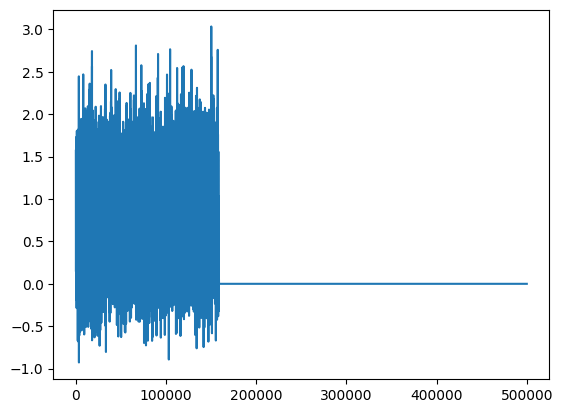

In [17]:
# X_design.shape
plt.plot(data.T)

In [21]:
X_design.shape

(57777, 1203)

In [74]:
grid_search.best_estimator_

Ridge(alpha=5.0)

In [7]:
# Check for available device
device = ('cuda' if torch.cuda.is_available() else 'cpu')

class Ridge:
    def __init__(self, input_dim, output_dim, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.loss_history = []
        
        # Define the nn.Linear layer with the fit_intercept parameter controlling bias
        self.linear = nn.Linear(input_dim, output_dim, bias=fit_intercept).to(device)

    def fit(self, X, y, epochs=1000, lr=0.01, momentum=0):
        n_samples = X.shape[0]
        
        optimizer = optim.SGD(self.linear.parameters(), lr=lr, momentum=momentum )


        # Convert data to CPU tensors only (avoiding full GPU memory usage initially)
        X_tensor = torch.tensor(X.todense(), dtype=torch.float32)  # Keep on CPU
        y_tensor = torch.tensor(y, dtype=torch.float32)  # Keep on CPU
        dataset = TensorDataset(X_tensor, y_tensor)
        data_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        # Training loop
        for epoch in range(epochs):
            epoch_loss = 0.0
            for X_batch, y_batch in data_loader:
                # Move mini-batch to GPU
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                
                # Forward pass
                predictions = self.model(X_batch)
                loss = self.loss(predictions, y_batch)
                epoch_loss += loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            avg_loss = epoch_loss / len(data_loader)
            self.loss_history.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")


            

    def model(self, x):
        return self.linear(x)

    def loss(self, predictions, y):
        mse_loss = torch.mean((predictions - y) ** 2)
        ridge_penalty = self.alpha * torch.sum(self.linear.weight ** 2)
        return mse_loss + ridge_penalty

    def predict(self, X):
        return self.model(X).detach().cpu().numpy()

    def plot_learning_curve(self):
        plt.plot(self.loss_history, label="Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Learning Curve")
        plt.legend()
        plt.show()

In [64]:
evts

,latency,type,categorical,continuous,effect
0,0.000000,0,NaN,NaN,NaN
1,6.507745,1,NaN,NaN,False
2,55.250512,0,NaN,NaN,NaN
3,58.813516,1,NaN,NaN,True
4,131.136892,0,NaN,NaN,NaN
...,...,...,...,...,...
1195,59235.908146,1,NaN,NaN,True
1196,59301.063636,0,NaN,NaN,NaN
1197,59300.275653,1,NaN,NaN,True
1198,59361.545860,0,NaN,NaN,NaN


In [73]:
plt.plot(rERP_model.coef_.T)

In [60]:
plt.plot(coeffs.T)

## playground

Epoch 1/500, Loss: 4.3107
Epoch 2/500, Loss: 4.0437
Epoch 3/500, Loss: 3.7977
Epoch 4/500, Loss: 3.5711
Epoch 5/500, Loss: 3.3624
Epoch 6/500, Loss: 3.1701
Epoch 7/500, Loss: 2.9930
Epoch 8/500, Loss: 2.8298
Epoch 9/500, Loss: 2.6794
Epoch 10/500, Loss: 2.5409
Epoch 11/500, Loss: 2.4133
Epoch 12/500, Loss: 2.2957
Epoch 13/500, Loss: 2.1873
Epoch 14/500, Loss: 2.0875
Epoch 15/500, Loss: 1.9954
Epoch 16/500, Loss: 1.9107
Epoch 17/500, Loss: 1.8325
Epoch 18/500, Loss: 1.7605
Epoch 19/500, Loss: 1.6942
Epoch 20/500, Loss: 1.6330
Epoch 21/500, Loss: 1.5767
Epoch 22/500, Loss: 1.5247
Epoch 23/500, Loss: 1.4768
Epoch 24/500, Loss: 1.4327
Epoch 25/500, Loss: 1.3920
Epoch 26/500, Loss: 1.3545
Epoch 27/500, Loss: 1.3200
Epoch 28/500, Loss: 1.2881
Epoch 29/500, Loss: 1.2588
Epoch 30/500, Loss: 1.2317
Epoch 31/500, Loss: 1.2067
Epoch 32/500, Loss: 1.1837
Epoch 33/500, Loss: 1.1625
Epoch 34/500, Loss: 1.1430
Epoch 35/500, Loss: 1.1249
Epoch 36/500, Loss: 1.1083
Epoch 37/500, Loss: 1.0930
Epoch 38/5

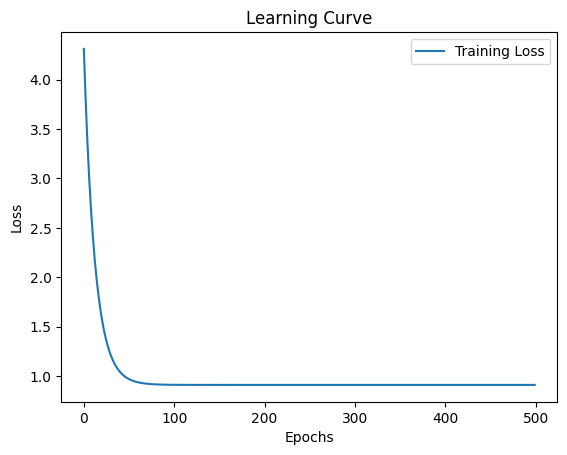

Predictions shape: (155307, 1)


In [13]:
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

class RidgeDeconvolution:
    def __init__(self, input_dim, output_dim, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.loss_history = []
        
        # Define the linear layer with an optional intercept (bias term)
        self.linear = nn.Linear(input_dim, output_dim, bias=fit_intercept).to(device)
        
        # Variables to store mean and std for normalization
        self.X_mean = None
        self.X_std = None
        self.y_mean = None
        self.y_std = None

    def normalize_data(self, X, y):
        # Compute mean and std for normalization
        self.X_mean = X.mean(dim=0, keepdim=True)
        self.X_std = X.std(dim=0, keepdim=True)
        self.y_mean = y.mean(dim=0, keepdim=True)
        self.y_std = y.std(dim=0, keepdim=True)

        # Normalize X and y
        X_normalized = (X - self.X_mean) / (self.X_std + 1e-8)  # Avoid division by zero
        y_normalized = (y - self.y_mean) / (self.y_std + 1e-8)
        
        return X_normalized, y_normalized

    def fit(self, X, y, epochs=1000, lr=0.01):
        # Normalize the data
        X, y = self.normalize_data(X, y)
        n_samples = X.shape[0]
        
        optimizer = optim.SGD(self.linear.parameters(), lr=lr)

        for epoch in range(epochs):
            # Shuffle indices at the start of each epoch
            indices = torch.randperm(n_samples)
            epoch_loss = 0.0
            num_batches = (n_samples + self.batch_size - 1) // self.batch_size

            for i in range(0, n_samples, self.batch_size):
                batch_indices = indices[i:i + self.batch_size]
                X_batch = X[batch_indices].to(self.device)
                y_batch = y[batch_indices].to(self.device)

                # Forward pass using the linear layer
                predictions = self.linear(X_batch)
                loss = self.loss(predictions, y_batch)
                epoch_loss += loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            avg_loss = epoch_loss / num_batches
            self.loss_history.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    def loss(self, predictions, y):
        mse_loss = torch.mean((predictions - y) ** 2)
        ridge_penalty = self.alpha * torch.sum(self.linear.weight ** 2)
        return mse_loss + ridge_penalty

    def predict(self, X):
        # Normalize the input X
        X_normalized = (X - self.X_mean) / (self.X_std + 1e-8)
        predictions_normalized = self.linear(X_normalized)
        
        # Rescale predictions to the original scale
        predictions = predictions_normalized * (self.y_std + 1e-8) + self.y_mean
        return predictions.detach().cpu().numpy()

    def plot_learning_curve(self):
        plt.plot(self.loss_history, label="Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Learning Curve")
        plt.legend()
        plt.show()

if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Generate or load your design matrix for deconvolution (X_design)
    # and your response vector/matrix (y_data), ensuring that X_design 
    # properly reflects event separation with a Toeplitz structure if needed.
    X_torch = torch.tensor(X_design.toarray()).float().to(device)  # Convert to dense PyTorch tensor
    y_torch = torch.tensor(y_data).float().to(device)

    # Instantiate and train the deconvolution Ridge model
    torch_ridge = RidgeDeconvolution(input_dim=X_design.shape[1], output_dim=1, alpha=9, fit_intercept=True, batch_size=500000, device=device)
    torch_ridge.fit(X_torch, y_torch, epochs=500, lr=0.002)
    
    # Plot learning curve
    torch_ridge.plot_learning_curve()

    # Predictions
    torch_predictions = torch_ridge.predict(X_torch)
    print("Predictions shape:", torch_predictions.shape)


In [3]:
# Updated PyTorch Ridge Model initialization
torch_ridge = Ridge(
    input_dim=X_design.shape[1], 
    output_dim=y_data.shape[1], 
    alpha=5,  
    fit_intercept=False, 
    batch_size=500000,  # 10x larger batch size
    device=device
)

# Train with increased learning rate and reduced epochs
torch_ridge.fit(
    X_design, 
    y_data, 
    epochs=150,           # Fewer epochs due to larger batch size
    lr=0.005,              # Increased learning rate
    momentum=0.5,         # Reduced momentum for stability
    scheduler_step_size=0, 
    scheduler_gamma=0  # Slower decay in learning rate
)

# Plot learning curve to assess convergence
torch_ridge.plot_learning_curve()


NameError: name 'Ridge' is not defined

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.


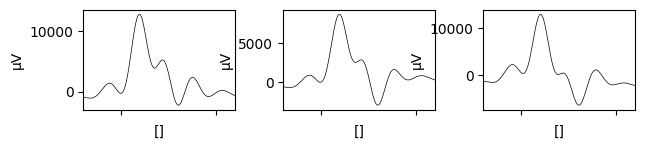

In [14]:
rERP_model.plot_coefs(top_topos=False)
plt.show()

Epoch 0/15, Total Loss: 0.138774, MSE: 0.138760, Ridge: 0.000014, Elapsed: 0:00:00, ETA: 0:00:00
Epoch 10/15, Total Loss: 0.020761, MSE: 0.020685, Ridge: 0.000076, Elapsed: 0:00:00, ETA: 0:00:00

Training completed in 0:00:00.242222


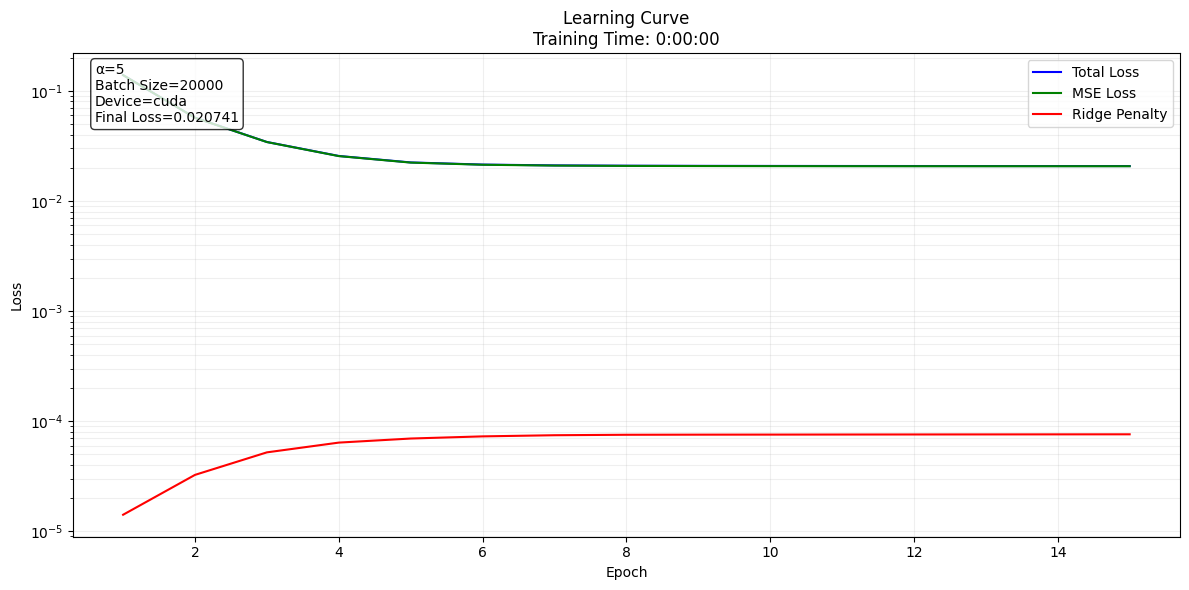

Predictions shape: (246140, 1)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.


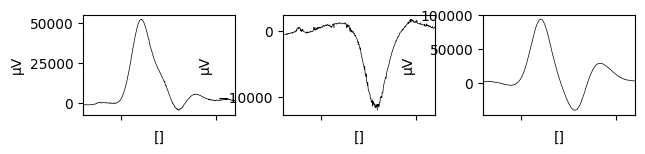

In [9]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import timedelta

class RidgeDeconvolution:
    def __init__(self, input_dim, output_dim, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.loss_history = {'total': [], 'mse': [], 'ridge': []}
        self.training_time = None
        
        # Initialize weights closer to zero
        self.linear = nn.Linear(input_dim, output_dim, bias=fit_intercept).to(device)
        nn.init.normal_(self.linear.weight, mean=0.0, std=0.01)
        if fit_intercept:
            nn.init.zeros_(self.linear.bias)
        
        self.X_mean = None
        self.X_std = None
        self.y_mean = None
        self.y_std = None

    def normalize_data(self, X, y):
        """Center the data like sklearn"""
        if self.X_mean is None:
            self.X_mean = X.mean(dim=0, keepdim=True)
            self.y_mean = y.mean(dim=0, keepdim=True)
            
            # Only scale X like sklearn's Ridge
            self.X_std = torch.sqrt(torch.sum((X - self.X_mean)**2, dim=0, keepdim=True) / X.shape[0])
            self.y_std = None  # Don't scale y
        
        # Center and scale X, only center y
        X_normalized = (X - self.X_mean) / (self.X_std + 1e-8)
        y_normalized = y - self.y_mean if self.fit_intercept else y
        
        return X_normalized, y_normalized

    def loss(self, predictions, y):
        """
        Implement loss exactly like sklearn's Ridge:
        Loss = (1/(2*n_samples)) * ||y - Xw||^2 + (alpha/(2*n_samples)) * ||w||^2
        """
        n_samples = y.shape[0]
        
        # MSE term
        mse_loss = torch.sum((predictions - y) ** 2) / (2 * n_samples)
        
        # L2 regularization term (exclude bias from regularization like sklearn)
        ridge_penalty = (self.alpha / (2 * n_samples)) * torch.sum(self.linear.weight ** 2)
        
        return mse_loss + ridge_penalty, mse_loss.item(), ridge_penalty.item()

    def fit(self, X, y, epochs=1000, lr=0.01):
        start_time = time.time()
        
        # Convert inputs to torch tensors if needed
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        if not isinstance(y, torch.Tensor):
            y = torch.tensor(y, dtype=torch.float32)
        
        # Move to device
        X = X.to(self.device)
        y = y.to(self.device)
        
        # Normalize data
        X, y = self.normalize_data(X, y)
        n_samples = X.shape[0]
        
        # Use Adam with very small epsilon like sklearn's default solver
        optimizer = optim.Adam(self.linear.parameters(), lr=lr, eps=1e-8)
        
        for epoch in range(epochs):
            total_loss = 0
            total_mse = 0
            total_ridge = 0
            num_batches = 0
            
            # Process in batches
            for i in range(0, n_samples, self.batch_size):
                batch_end = min(i + self.batch_size, n_samples)
                X_batch = X[i:batch_end]
                y_batch = y[i:batch_end]
                
                optimizer.zero_grad()
                predictions = self.linear(X_batch)
                loss, mse, ridge = self.loss(predictions, y_batch)
                loss.backward()
                
                # Gradient clipping for stability
                torch.nn.utils.clip_grad_norm_(self.linear.parameters(), max_norm=1.0)
                
                optimizer.step()
                total_loss += loss.item() * (batch_end - i)
                total_mse += mse * (batch_end - i)
                total_ridge += ridge * (batch_end - i)
                num_batches += 1
            
            # Calculate average losses
            avg_loss = total_loss / n_samples
            avg_mse = total_mse / n_samples
            avg_ridge = total_ridge / n_samples
            
            # Store losses
            self.loss_history['total'].append(avg_loss)
            self.loss_history['mse'].append(avg_mse)
            self.loss_history['ridge'].append(avg_ridge)
            
            # Early stopping if loss is stable
            if epoch > 10 and abs(self.loss_history['total'][-1] - self.loss_history['total'][-2]) < 1e-7:
                print(f"Converged at epoch {epoch}")
                break
            
            if epoch % 10 == 0:
                elapsed = time.time() - start_time
                eta = (elapsed / (epoch + 1)) * (epochs - epoch - 1)
                print(f"Epoch {epoch}/{epochs}, Total Loss: {avg_loss:.6f}, "
                      f"MSE: {avg_mse:.6f}, Ridge: {avg_ridge:.6f}, "
                      f"Elapsed: {timedelta(seconds=int(elapsed))}, "
                      f"ETA: {timedelta(seconds=int(eta))}")
        
        self.training_time = time.time() - start_time
        print(f"\nTraining completed in {timedelta(seconds=self.training_time)}")

    def predict(self, X):
        """Predict like sklearn's Ridge"""
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        
        X = X.to(self.device)
        
        self.linear.eval()
        with torch.no_grad():
            X_normalized = (X - self.X_mean) / (self.X_std + 1e-8)
            predictions = self.linear(X_normalized)
            if self.fit_intercept:
                predictions = predictions + self.y_mean
            
        return predictions.cpu().numpy()

    def get_coefficients(self):
        """Get coefficients in the original scale like sklearn"""
        with torch.no_grad():
            # Get weights
            weights = self.linear.weight.cpu()
            
            # Rescale weights
            scaled_weights = weights / (self.X_std + 1e-8).cpu()
            
            # Get intercept if fitted
            if self.fit_intercept:
                intercept = self.y_mean.cpu() - torch.mm(self.X_mean.cpu(), scaled_weights.t())
            else:
                intercept = torch.zeros(self.linear.out_features)
            
            return scaled_weights.numpy(), intercept.numpy()

    def plot_learning_curve(self, log_scale=True):
        """
        Plot the learning curve showing total loss, MSE, and ridge penalty components
        """
        plt.figure(figsize=(12, 6))
        epochs = range(1, len(self.loss_history['total']) + 1)
        
        plt.plot(epochs, self.loss_history['total'], 'b-', label='Total Loss')
        plt.plot(epochs, self.loss_history['mse'], 'g-', label='MSE Loss')
        plt.plot(epochs, self.loss_history['ridge'], 'r-', label='Ridge Penalty')
        
        plt.title(f'Learning Curve\nTraining Time: {timedelta(seconds=int(self.training_time))}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        
        if log_scale:
            plt.yscale('log')
        
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.legend()
        
        # Add training details as text
        details = (f'α={self.alpha}\n'
                  f'Batch Size={self.batch_size}\n'
                  f'Device={self.device}\n'
                  f'Final Loss={self.loss_history["total"][-1]:.6f}')
        plt.text(0.02, 0.98, details, 
                transform=plt.gca().transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Generate or load your design matrix for deconvolution (X_design)
    # and your response vector/matrix (y_data), ensuring that X_design 
    # properly reflects event separation with a Toeplitz structure if needed.
    X_torch = torch.tensor(X_design.toarray()).float().to(device)  # Convert to dense PyTorch tensor
    y_torch = torch.tensor(y_data).float().to(device)

    # Instantiate and train the deconvolution Ridge model
    torch_ridge = RidgeDeconvolution(input_dim=X_design.shape[1], output_dim=1, alpha=5, fit_intercept=True, batch_size=20000, device=device)
    torch_ridge.fit(X_torch, y_torch, epochs=15, lr=0.002)
    
    # Plot learning curve
    torch_ridge.plot_learning_curve()

    # Predictions
    torch_predictions = torch_ridge.predict(X_torch)
    print("Predictions shape:", torch_predictions.shape)
    coeffs =  torch_ridge.linear.weight.detach().cpu().numpy()
    rERP_model.coef_ =  coeffs
    # # Predictions should now have shape (13000, 3)
    # torch_predictions = torch_ridge.predict(X_torch)
    rERP_model.plot_coefs(top_topos=False)


In [3]:
best_model

NameError: name 'best_model' is not defined

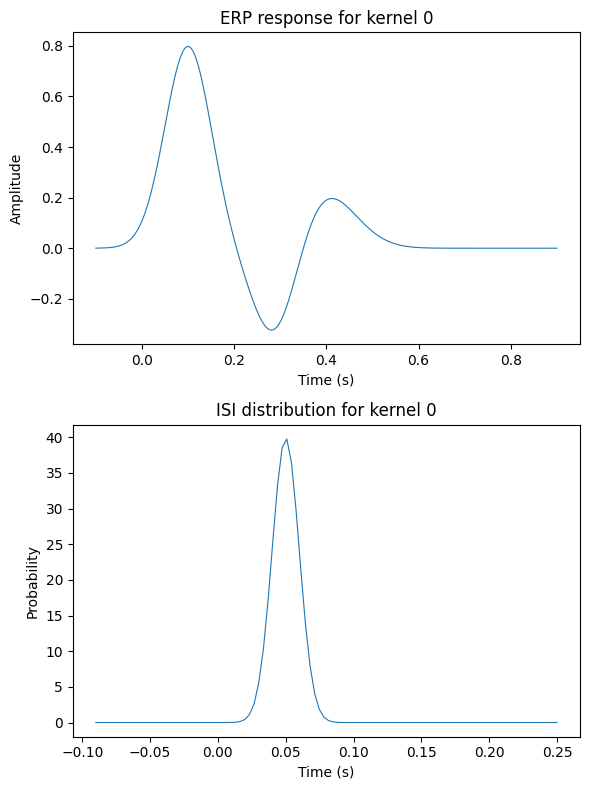

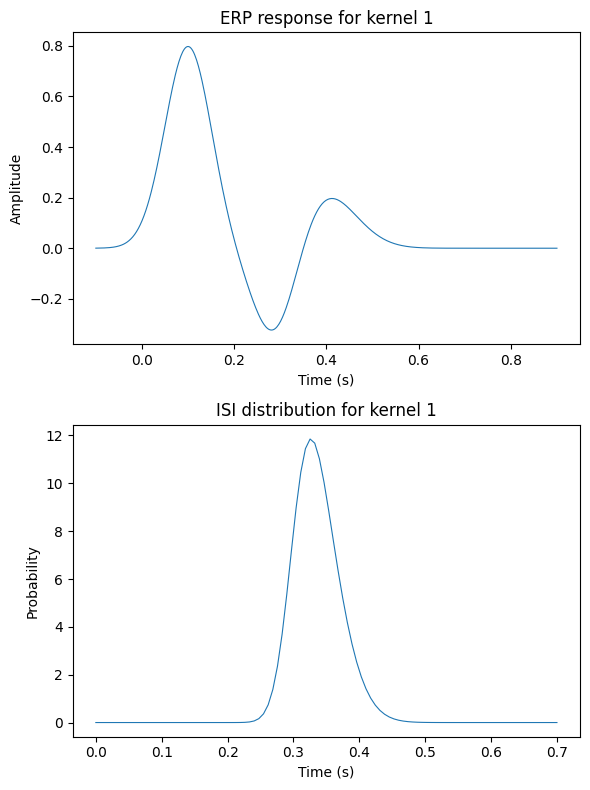

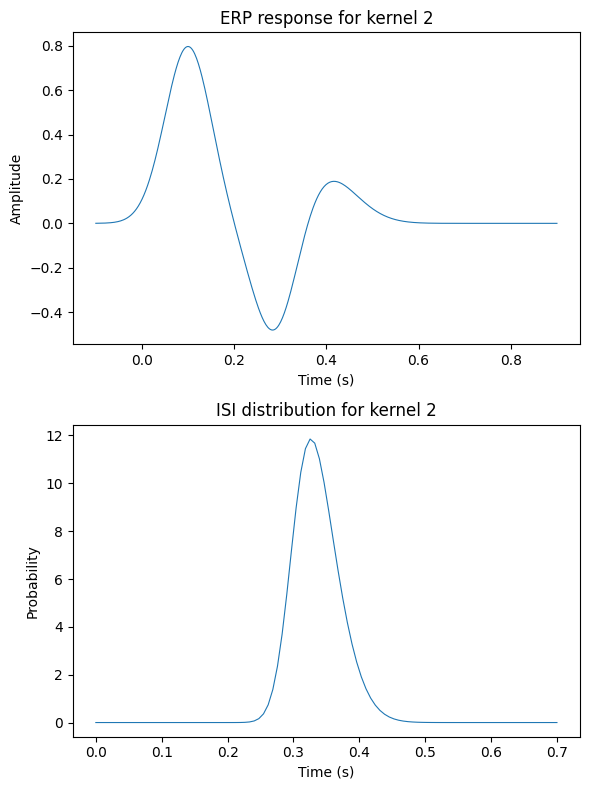

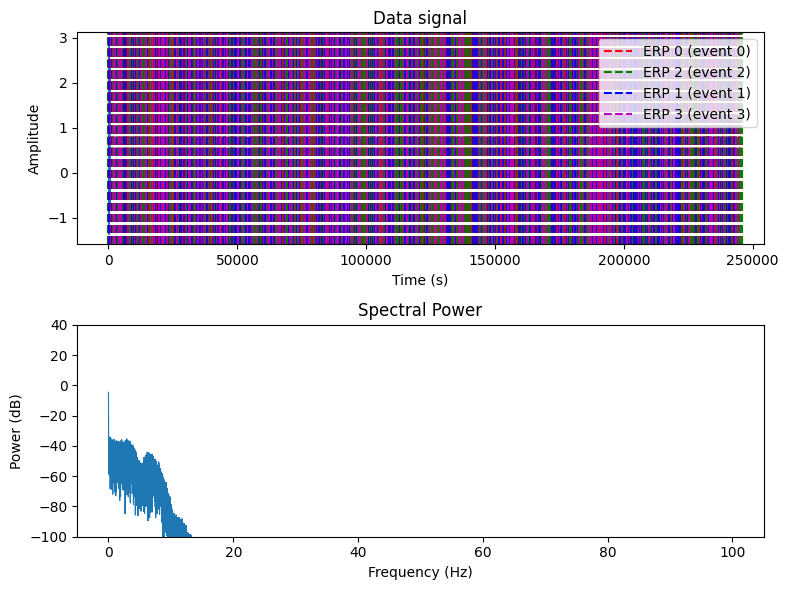

Mean:    0.41829639298265714 
Median:    0.0
Variance:  0.3599787716713756


In [13]:
sig.plot_response_idx(0)
sig.plot_response_idx(1)
sig.plot_response_idx(2)
plt.show()
sig.plot_datanpsd()
sig.data_stats()
plt.show()
